| i | Xi  | Yi  |
|---|-----|-----|
| 1 | 0.66 | 22.90 |
| 2 | 0.16 | 12.40 |
| 3 | 0.44 | 27.00 |
| 4 | 2.00 | 7.69 |
| 5 | 1.55 | 58.40 |
| 6 | 2.00 | 43.00 |
| 7 | 0.18 | 32.30 |
| 8 | 0.86 | 36.60 |

In [ ]:
# Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# input Data

Data = {
    "TT": [0.66, 0.16, 0.44, 2.00, 1.55, 2.00, 0.18, 0.86],
    "TR": [22.90, 12.40, 27.00, 7.69, 58.40, 43.00, 32.30, 36.60]
}

Data_contoh = pd.DataFrame(Data)
Data_contoh

In [ ]:
Data_contoh.plot(kind='scatter', x="TT", y="TR")

In [ ]:
# Konversi ke array

x = np.array(Data_contoh['TT']).reshape(-1,1)
y = np.array(Data_contoh['TR']).reshape(-1,1)

print(f'X = \n', x)
print(f'Y = \n', y)

In [ ]:
d = y.copy()
n_data = len(d)
n_par = 2

G = np.zeros((n_data, n_par))

for i in range(n_data):
    G[i,0] = x[i][0]
    G[i,1] = 1

print(f'd = \n', d)
print(f'G = \n', G)

<function matplotlib.pyplot.show(close=None, block=None)>

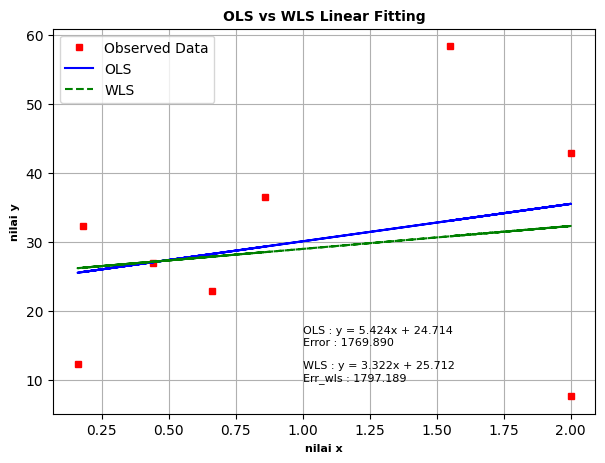

In [24]:
# OLS
m, residuals, rank, s = np.linalg.lstsq(G,y)

slope = float(m[0][0])
intercept = float (m[1][0])
Err = float(residuals[0])

dcal = G @ m

# WLS
W = np.eye(n_data)
W[5,5] = 0.2

A = G.T @ W @ G
B = G.T @ W @ y
m_wls = np.linalg.solve(A, B)

slope_w = float(m_wls[0][0])
intercept_w = float(m_wls[1][0])

dcal_wls = G @ m_wls
Err_wls = np.sum((y - dcal_wls)**2)

plt.figure(figsize = (7,5))

plt.plot(x, y, 'rs', markersize = 4, label = 'Observed Data')
plt.plot(x, dcal, 'b-', markersize = 8, label = 'OLS')
plt.plot(x, dcal_wls, 'g--', markersize = 8, label = 'WLS')
plt.title('OLS vs WLS Linear Fitting', fontsize = 10, fontweight = 'bold')
plt.xlabel('nilai x', fontsize = 8, fontweight ='bold')
plt.ylabel('nilai y', fontsize = 8, fontweight ='bold')
plt.legend()
plt.grid()

txt_str = (
    f'OLS : y = {slope:.3f}x + {intercept:.3f}\n'
    f'Error : {Err:.3f} \n\n'
    f'WLS : y = {slope_w:.3f}x + {intercept_w:.3f}\n'
    f"Err_wls : {Err_wls:.3f}"
)

plt.text(1, 10, txt_str, fontsize = 8)
plt.show